# データサイエンス講座(統計編) 19〜22 確率論

In [1]:
import math

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 19 二項分布をPythonを使って理解する(最も基本的な確率分布)

[二項分布をPythonを使って理解する(最も基本的な確率分布)【統計学入門19】 - 米国データサイエンティストのブログ](https://datawokagaku.com/binominal_dist/)

- **二項分布**
	- PMF: `scipy.stats.binom.pmf(k, n, p, loc=0)`
	- 乱数生成: `scipy.stats.binom.rvs(n, p, loc=0, size=1, random_state=None)`
	- 期待値: `scipy.stats.binom.mean(n, p, loc=0)`
	- 分散: `scipy.stats.binom.var(n, p, loc=0)`

[scipy.stats.binom — SciPy v1.17.0 Manual](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html)

### 確率質量関数 (PMF)

In [2]:
def my_binom_pmf(x: int, n: int, p: float):
    return math.comb(n, x) * p**x * (1 - p) ** (n - x)

In [3]:
n = 3
p = 1 / 6
[my_binom_pmf(x, n, p) for x in range(n + 1)]

[0.5787037037037038,
 0.34722222222222227,
 0.06944444444444445,
 0.0046296296296296285]

In [4]:
[stats.binom.pmf(x, n, p) for x in range(n + 1)]

[np.float64(0.5787037037037036),
 np.float64(0.3472222222222223),
 np.float64(0.06944444444444445),
 np.float64(0.0046296296296296285)]

### 乱数生成：期待値と分散

In [5]:
n = 3
p = 1 / 6
size = 2160
rng = np.random.default_rng(1728)
data_binom = stats.binom.rvs(n, p, size=size, random_state=rng)
data_binom

array([1, 1, 1, ..., 2, 0, 1], shape=(2160,))

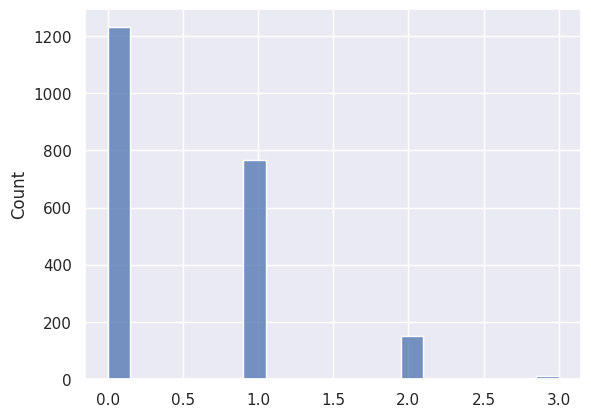

In [6]:
sns.set_theme()
fig, axes = plt.subplots()
sns.histplot(data=data_binom, kde=False, ax=axes)
plt.show()

度数を理論値と比較

In [7]:
np.unique(data_binom, return_counts=True)

(array([0, 1, 2, 3]), array([1233,  766,  150,   11]))

In [8]:
[stats.binom.pmf(x, n, p) * size for x in range(n + 1)]

[np.float64(1249.9999999999998),
 np.float64(750.0000000000002),
 np.float64(150.0),
 np.float64(9.999999999999998)]

二項分布の期待値は $np$、分散は $np(1-p)$となる。これを生成した乱数で確かめてみる。

平均

In [9]:
np.mean(data_binom)

np.float64(0.5087962962962963)

In [10]:
stats.binom.mean(n, p)

np.float64(0.5)

分散

In [11]:
np.var(data_binom)

np.float64(0.4193670696159123)

In [12]:
stats.binom.var(n, p)

np.float64(0.4166666666666667)

## 20 ポワソン分布を完全解説！正規分布や二項分布との関係は？

[ポワソン分布を完全解説！正規分布や二項分布との関係は？【統計学入門20】 - 米国データサイエンティストのブログ](https://datawokagaku.com/poisson_dist/)

**注意**: ポアソン分布の母数は $\lambda$ で表すことが多いが、ここでは SciPy の流儀に合わせて $\mu$ で表記する。

- **ポアソン分布**
	- PMF: `scipy.stats.poisson.pmf(k, mu, loc=0)`
	- CDF: `scipy.stats.poisson.cdf(k, mu, loc=0)`
	- 期待値: `scipy.stats.poisson.mean(mu, loc=0)`
	- 分散: `scipy.stats.poisson.var(mu, loc=0)`
	- 乱数生成: `scipy.stats.poisson.rvs(mu, loc=0, size=1, random_state=None)`

参照：[scipy.stats.poisson — SciPy v1.17.0 Manual](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html)

### 少数の法則

**例**：100個に1個の割合で不良品が発生する。500個ずつ箱に梱包したとき、1箱に不良品が5個入っている確率

二項分布の場合 ($n = 500, p = 1 / 100$)

In [13]:
stats.binom.pmf(5, 500, 1 / 100)

np.float64(0.17635104507334973)

ポアソン分布の場合 ($\mu = 5$)

In [14]:
def my_poisson_pmf(x: int, mu: float):
    return mu**x * math.exp(-mu) / math.factorial(x)

In [15]:
my_poisson_pmf(5, 5)

0.1754673697678507

In [16]:
stats.poisson.pmf(k=5, mu=5)

np.float64(0.17546736976785068)

ポアソン分布で計算した確率は、確かに二項分布の確率に近い。

次に、実際に $n$ を大きくして、二項分布の確率分布をプロットしてみる。

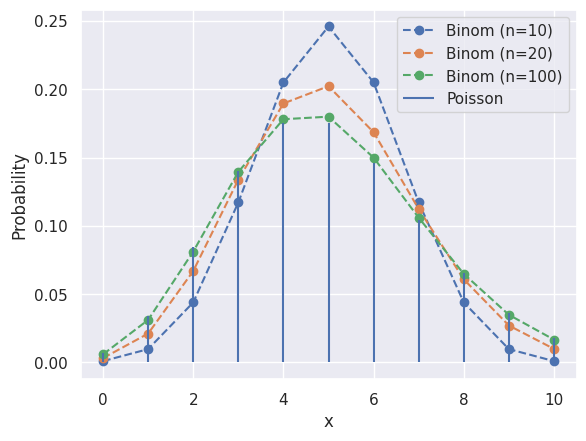

In [17]:
mu = 5
n_list = [10, 20, 100]

x = np.arange(11)

fig, axes = plt.subplots()
# 二項分布を描画
for n in n_list:
    axes.plot(x, stats.binom.pmf(k=x, n=n, p=mu / n), "o--", label=f"Binom (n={n})")
# ポアソン分布を描画
axes.vlines(x, 0, stats.poisson.pmf(k=x, mu=mu), label=f"Poisson")
axes.legend()
axes.set_xlabel("x")
axes.set_ylabel("Probability")
plt.show()

$n$が大きくなるにつれ、二項分布がポアソン分布に近づいている事が確認できる。

### 確率分布

**例**: 10分間に平均5回鳴るコールセンターで、1時間に40回電話が鳴る確率は？

$\mu = 5 / 10 \times 60 = 30$ なので、

In [18]:
mu = 30
x = 40
stats.poisson.pmf(k=x, mu=mu)

np.float64(0.013943463479967897)

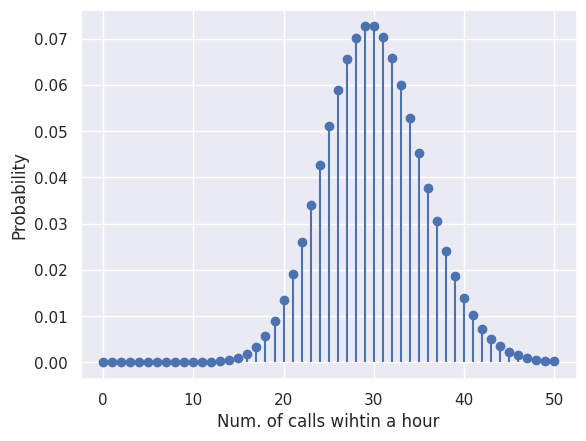

In [19]:
x = np.arange(51)
prob_list = stats.poisson.pmf(x, mu)

fig, axes = plt.subplots()
axes.plot(x, prob_list, "o")
axes.vlines(x, 0, prob_list)
axes.set_xlabel("Num. of calls wihtin a hour")
axes.set_ylabel("Probability")
plt.show()

最頻値となる $x=30$でも、確率は7%程度である。「ちょうどその回数」となる確率は高くない。

In [20]:
1 - stats.poisson.cdf(k=(35 - 1), mu=mu)

np.float64(0.20269167451688286)

In [21]:
1 - stats.poisson.cdf(k=(40 - 1), mu=mu)

np.float64(0.0462530376458421)

$x \ge 35$ となる確率は20%、$x \ge 40$ となる確率は4.6%となる。離散確率なので、CDF（累積分布関数）の引数で1引いている事に注意

### 期待値と分散

ポアソン分布の期待値と分散は共に $\mu$ となる。

In [22]:
mu = 30
stats.poisson.mean(mu)

np.float64(30.0)

In [23]:
stats.poisson.var(mu)

np.float64(30.0)

乱数生成をして確かめてみる。

In [24]:
size = 1000
rng = np.random.default_rng(1728)
data_poisson = stats.poisson.rvs(mu, size=size, random_state=rng)

ヒストグラム

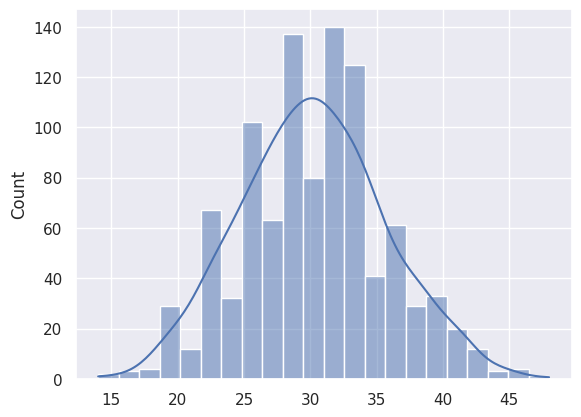

In [25]:
fig, axes = plt.subplots()
sns.histplot(data=data_poisson, kde=True, ax=axes)
plt.show()

平均と分散

In [26]:
np.mean(data_poisson)

np.float64(30.191)

In [27]:
np.var(data_poisson)

np.float64(29.694519)

共に $\mu = 30$ に近いことが確かめられた。

## 21 幾何分布と指数分布を解説！ポワソン分布との関係は？

[幾何分布と指数分布を解説！ポワソン分布との関係は？【統計学入門21】 - 米国データサイエンティストのブログ](https://datawokagaku.com/geom_expon_dist/)


- **幾何分布**
	- PMF: `scipy.stats.geom.pmf(k, p, loc=0)`
	- 期待値: `scipy.stats.geom.mean(p, loc=0)`
	- 分散: `scipy.stats.geom.var(p, loc=0)`
	- 乱数生成: `scipy.stats.geom.rvs(p, loc=0, size=1, random_state=None)`

参照：[scipy.stats.geom — SciPy v1.18.0 Manual](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.geom.html)

- **指数分布（尺度母数$1/\lambda$は引数`scale`で指定）**
	- PDF: `scipy.stats.expon.pmf(x, loc=0, scale=1)`
	- CDF: `scipy.stats.expon.cdf(x, loc=0, scale=1)`
	- 期待値: `scipy.stats.expon.mean(loc=0, scale=1)`
	- 分散: `scipy.stats.expon.var(loc=0, scale=1)`
	- 乱数生成: `scipy.stats.expon.rvs(loc=0, scale=1, size=1, random_state=None)`

参照：[scipy.stats.expon — SciPy v1.18.0 Manual](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html)


### 幾何分布 (Geometric distribution)

In [28]:
def my_geom_pmf(x: int, p: float):
    return (1 - p) ** (x - 1) * p

In [29]:
p = 1 / 6
x_list = range(1, 6)
[my_geom_pmf(x, p) for x in x_list]

[0.16666666666666666,
 0.1388888888888889,
 0.11574074074074076,
 0.09645061728395063,
 0.08037551440329219]

In [30]:
[stats.geom.pmf(x, p) for x in x_list]

[np.float64(0.16666666666666666),
 np.float64(0.1388888888888889),
 np.float64(0.11574074074074076),
 np.float64(0.09645061728395063),
 np.float64(0.08037551440329219)]

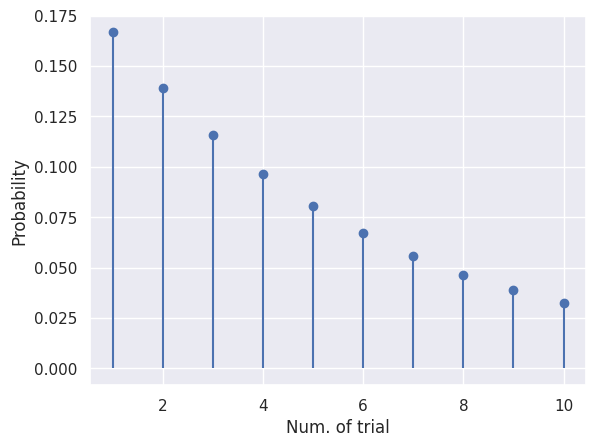

In [31]:
x = range(1, 11)
y = stats.geom.pmf(x, p)

fig, axes = plt.subplots()
axes.plot(x, y, "o")
axes.vlines(x, 0, y)
axes.set_xlabel("Num. of trial")
axes.set_ylabel("Probability")
plt.show()

### 幾何分布の期待値と分散

幾何分布の期待値は$1/p$、分散は $(1-p)/p^2$ となる。

In [32]:
p = 1 / 6
stats.geom.mean(p)

np.float64(6.0)

In [33]:
stats.geom.var(p)

np.float64(30.000000000000007)

乱数生成をして確かめてみる。

In [34]:
size = 1000
rng = np.random.default_rng(1728)
data_geom = stats.geom.rvs(p, size=size, random_state=rng)

ヒストグラム

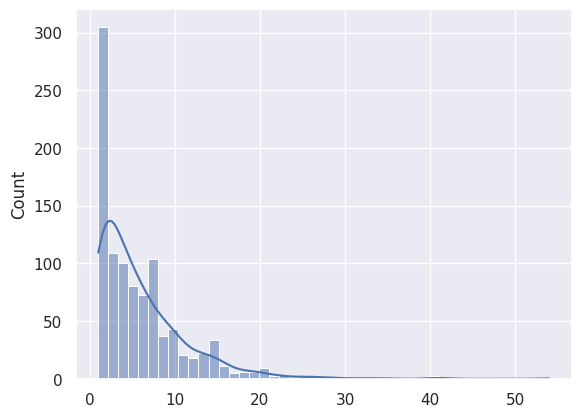

In [35]:
fig, axes = plt.subplots()
sns.histplot(data=data_geom, kde=True, ax=axes)
plt.show()

平均と分散

In [36]:
np.mean(data_geom)

np.float64(5.95)

In [37]:
np.var(data_geom)

np.float64(29.7775)

共に理論値に近いことが確かめられた。

### 指数分布 (Geometric distribution)

In [38]:
def my_expon_pdf(x: float, scale: float):
    return math.exp(-x / scale) / scale

In [39]:
lam = 10 / 60
scale = 1 / lam
x = 5
my_expon_pdf(x, scale)

0.0724330347511797

In [40]:
stats.expon.pdf(x, scale=scale)

np.float64(0.0724330347511797)

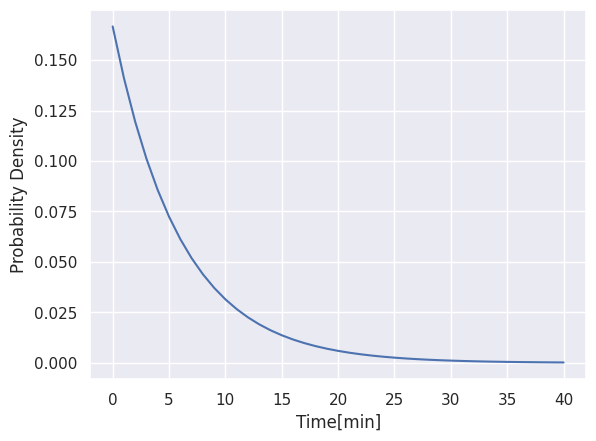

In [41]:
x = range(0, 41)
y = stats.expon.pdf(x, scale=scale)

fig, axes = plt.subplots()
axes.plot(x, y)
axes.set_xlabel("Time[min]")
axes.set_ylabel("Probability Density")
plt.show()

In [42]:
stats.expon.cdf(5, scale=scale)

np.float64(0.5654017914929218)

### 指数分布の期待値と分散

指数分布の期待値は$1/\lambda = \theta$、分散は $1/\lambda^2 = \theta^2$ となる。

In [43]:
lam = 1 / 6
scale = 1 / lam
stats.expon.mean(scale=scale)

np.float64(6.0)

In [44]:
stats.expon.var(scale=scale)

np.float64(36.0)

乱数生成をして確かめてみる。

In [45]:
size = 1000
rng = np.random.default_rng(1728)
data_exp = stats.expon.rvs(scale=scale, size=size, random_state=rng)

ヒストグラム

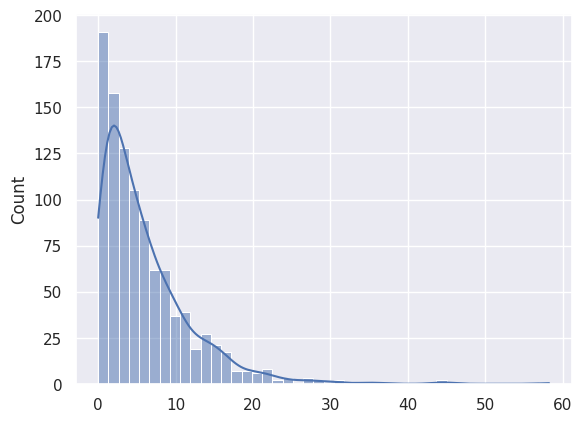

In [46]:
fig, axes = plt.subplots()
sns.histplot(data=data_exp, kde=True, ax=axes)
plt.show()

平均と分散

In [47]:
np.mean(data_exp)

np.float64(5.944093619768581)

In [48]:
np.var(data_exp)

np.float64(35.69083040632959)

## 22 正規分布の正体を暴く

[正規分布の正体を暴く【統計学入門22】 - 米国データサイエンティストのブログ](https://datawokagaku.com/what_is_norm_dist/)

- **正規分布**
	- PDF: `scipy.stats.norm.pdf(x, loc=0, scale=1)`
	- CDF: `scipy.stats.norm.cdf(x, loc=0, scale=1)`
	- 期待値: `scipy.stats.norm.mean(loc=0, scale=1)`
	- 分散: `scipy.stats.norm.var(loc=0, scale=1)`
	- 乱数生成: `scipy.stats.geom.rvs(loc=0, scale=1, size=1, random_state=None)`

参照：[scipy.stats.norm — SciPy v1.18.0 Manual](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html)

### 確率密度関数 (PDF)

In [49]:
def my_norm_pdf(x: float, loc: float = 0, scale: float = 1):
    return np.exp(-((x - loc) ** 2) / (2 * scale**2)) / (math.sqrt(2 * math.pi) * scale)

例：偏差値 ($\mu = 50, \sigma = 10$)

In [50]:
mu = 50
sigma = 10

x = np.arange(30, 71, 10)
my_norm_pdf(x, loc=mu, scale=sigma)

array([0.0053991 , 0.02419707, 0.03989423, 0.02419707, 0.0053991 ])

In [51]:
stats.norm.pdf(x, loc=mu, scale=sigma)

array([0.0053991 , 0.02419707, 0.03989423, 0.02419707, 0.0053991 ])

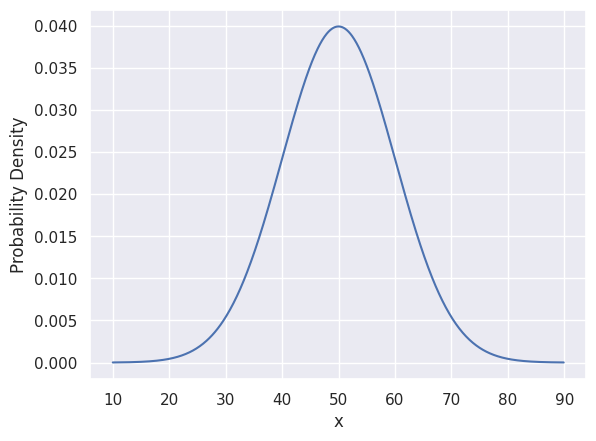

In [52]:
fig, axes = plt.subplots()
x = np.arange(10, 90, 0.1)
y = stats.norm.pdf(x, loc=mu, scale=sigma)
axes.plot(x, y)

axes.set_xlabel("x")
axes.set_ylabel("Probability Density")
plt.show()

偏差値60

In [53]:
1 - stats.norm.cdf(x=60, loc=mu, scale=sigma)

np.float64(0.15865525393145707)

偏差値70

In [54]:
1 - stats.norm.cdf(x=70, loc=mu, scale=sigma)

np.float64(0.02275013194817921)

### 期待値と分散

正規分布$N(\mu, \sigma^2)$の期待値は$\mu$、分散は $\sigma^2$ となる。

In [55]:
mu = 0
sigma = 1
stats.norm.mean(loc=mu, scale=sigma)

np.float64(0.0)

In [56]:
stats.norm.var(loc=mu, scale=sigma)

np.float64(1.0)

乱数生成をして確かめてみる。

In [57]:
size = 1000
rng = np.random.default_rng(1728)
data_norm = stats.norm.rvs(loc=mu, scale=sigma, size=size, random_state=rng)

ヒストグラム

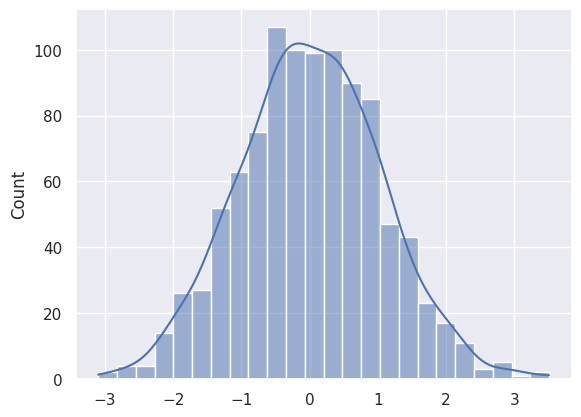

In [58]:
fig, axes = plt.subplots()
sns.histplot(data=data_norm, kde=True, ax=axes)
plt.show()

$k \sigma$ より大きくなる確率

In [59]:
for k in [1, 2, 3]:
    print(
        f"Probability of greater than {k}: {stats.norm.cdf(x=-k, loc=mu, scale=sigma):.3f}"
    )
    print(f"Samples of greater than {k}: {np.count_nonzero(data_norm > k) / size:.3f}")

Probability of greater than 1: 0.159
Samples of greater than 1: 0.167
Probability of greater than 2: 0.023
Samples of greater than 2: 0.029
Probability of greater than 3: 0.001
Samples of greater than 3: 0.003


平均と分散

In [60]:
np.mean(data_norm)

np.float64(0.012092411878496589)

In [61]:
np.var(data_norm)

np.float64(1.064604085685525)

### 二項分布の正規近似

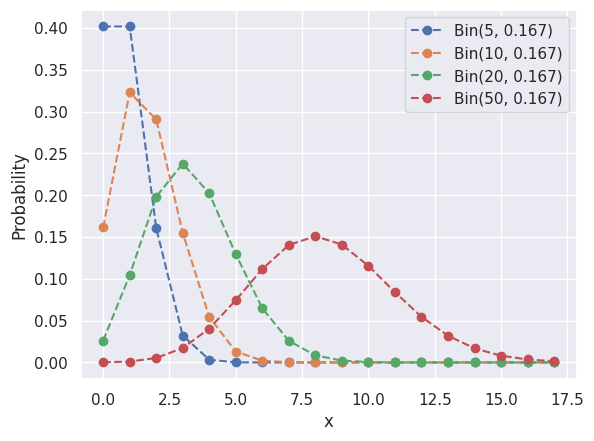

In [62]:
n_list = [5, 10, 20, 50]
p = 1 / 6
x = np.arange(18)

fig, axes = plt.subplots()
for n in n_list:
    axes.plot(x, stats.binom.pmf(k=x, n=n, p=p), "o--", label=f"Bin({n}, {p:.3f})")
axes.legend()
axes.set_xlabel("x")
axes.set_ylabel("Probability")
plt.show()

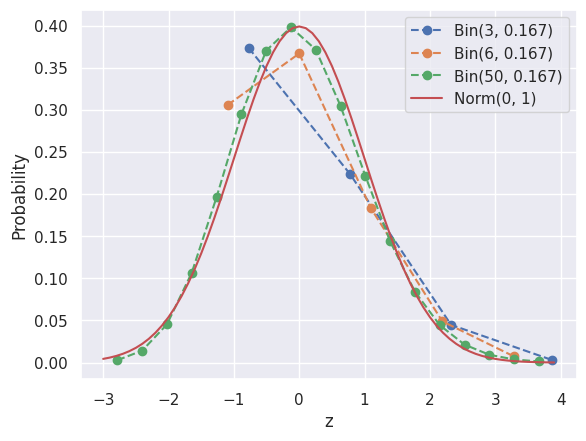

In [63]:
n_list = [3, 6, 50]
p = 1 / 6

# 描画する範囲（横軸）
z_range = (-3, 4)

fig, axes = plt.subplots()
# 標準化した二項分布
for n in n_list:
    x = np.arange(n + 1)

    mu = n * p
    sigma = np.sqrt(n * p * (1 - p))
    # 変数変換（標準化）
    z = (x - mu) / sigma
    y_z = stats.binom.pmf(k=x, n=n, p=p) * sigma
    # 描画範囲を0付近に限定
    z_filter = (z >= z_range[0]) & (z <= z_range[1])
    axes.plot(z[z_filter], y_z[z_filter], "o--", label=f"Bin({n}, {p:.3f})")

# 標準正規分布
z = np.arange(z_range[0], z_range[1], 0.1)
y_z = stats.norm.pdf(x=z)
axes.plot(z, y_z, label=f"Norm(0, 1)")

axes.legend()
axes.set_xlabel("z")
axes.set_ylabel("Probability")
plt.show()

### ポアソン分布の正規近似

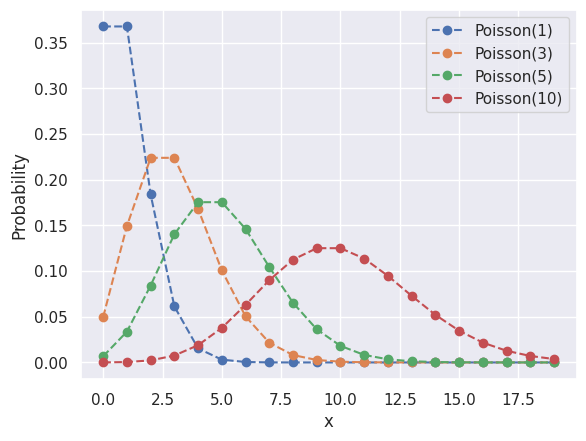

In [64]:
mu_list = [1, 3, 5, 10]
x = np.arange(20)

fig, axes = plt.subplots()
for mu in mu_list:
    axes.plot(x, stats.poisson.pmf(x, mu), "o--", label=f"Poisson({mu})")
axes.legend()
axes.set_xlabel("x")
axes.set_ylabel("Probability")
plt.show()

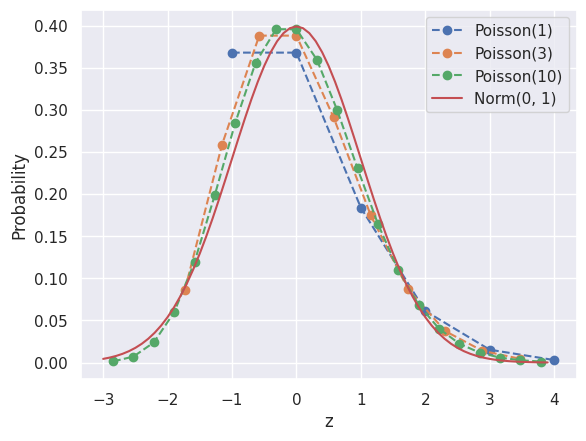

In [65]:
mu_list = [1, 3, 10]

# 描画する範囲（横軸）
z_range = (-3, 4)

fig, axes = plt.subplots()
# 標準化したポアソン分布
for mu in mu_list:
    x = np.arange(30)

    # 変数変換（標準化）
    sigma = np.sqrt(mu)
    z = (x - mu) / sigma
    y_z = stats.poisson.pmf(x, mu) * sigma
    # 描画範囲を0付近に限定
    z_filter = (z >= z_range[0]) & (z <= z_range[1])
    axes.plot(z[z_filter], y_z[z_filter], "o--", label=f"Poisson({mu})")

# 標準正規分布
z = np.arange(z_range[0], z_range[1], 0.1)
y_z = stats.norm.pdf(x=z)
axes.plot(z, y_z, label=f"Norm(0, 1)")

axes.legend()
axes.set_xlabel("z")
axes.set_ylabel("Probability")
plt.show()